In [2]:
import EFC_learningfMRI.globals as gl
import os
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np
import nitools as nt
from EFC_learningfMRI.vis import plot_im_sess, custom_legend
from imaging_pipelines.vis import plot_surf
import PcmPy as pcm
from EFC_learningfMRI.G_matrix import G_sorted
from EFC_learningfMRI.util import get_trained_and_untrained, ttest_im_sess
from EFC_learningfMRI.pcm import make_models
from matplotlib.colors import LinearSegmentedColormap, Normalize
import statsmodels.formula.api as smf
import itertools
import nibabel as nb
import warnings

warnings.filterwarnings('ignore')

base directory found: /cifs/diedrichsen/data/Chord_exp/EFC_learningfMRI
Atlas directory found: atlases
figure directory found: figures/


In [3]:
H     = 'L'
atlas = 'ROI'
rois  = gl.rois[atlas]
glm   = 3
sns   = gl.participants

# Representational geometry at session 3
*Compare with model components below

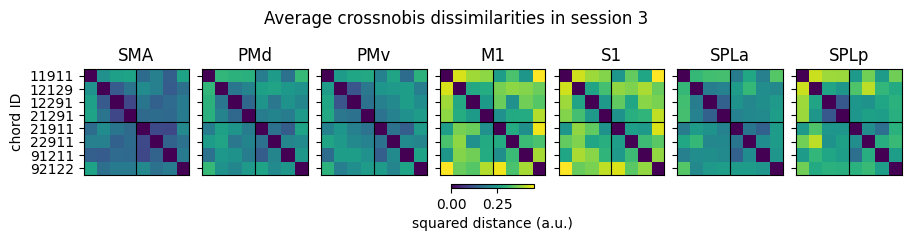

In [7]:
session = 3

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, constrained_layout=True, figsize=(9, 2.3))

vmin, vmax = 0, .45

for r, roi in enumerate(rois):
    G  = []
    for sn in sns:
        G.append(np.load(os.path.join(gl.baseDir, gl.pcmDir, f'subj{sn}', f'G_obs_raw.within_session.{session}.glm{glm}.{H}.{roi}.npy')))
    G  = np.array(G)

    ax = axs[r]
    G_sort  = G_sorted(G, sns, order=gl.chordID)
    D  = pcm.G_to_dist(G_sort)
    D  = np.sign(D) * np.sqrt(np.abs(D))
    im = ax.imshow(D.mean(axis=0), vmin=vmin, vmax=vmax)
    ax.axhline(3.5, lw=.8, color='k')
    ax.axvline(3.5, lw=.8, color='k')
    ax.set_xticks([])
    ax.set_yticks(np.arange(8))
    #ax.set_xticklabels(gl.chordID, rotation=90)
    ax.set_yticklabels(gl.chordID)
    ax.set_title(roi)

axs[0].set_ylabel('chord ID')

fig.colorbar(im, ax=axs, fraction=.03, label='squared distance (a.u.)', orientation='horizontal')

fig.suptitle(f'Average crossnobis dissimilarities in session 3')

fig.savefig(f'figures/crossnobis_example_{sn}.pdf')

plt.show()

# Crossnobis dissimilarities between activity patterns for trained and untrained chords (ROI-based)
In M1, activity patterns for trained chords on session 23 are slightly more distant among each other compared to untrained chords. This difference is not reliable across participants

           T  dof     p_val           CI95   roi  session
0  -0.536513   15  0.599471  [-0.02, 0.01]   SMA        3
3  -0.339298   15  0.739089  [-0.02, 0.01]   PMd        3
6  -0.512439   15  0.615806  [-0.03, 0.02]   PMv        3
9  -0.316506   15  0.755981  [-0.05, 0.04]    M1        3
12 -0.622612   15  0.542890  [-0.04, 0.02]    S1        3
15 -1.163322   15  0.262871  [-0.05, 0.01]  SPLa        3
18 -0.865556   15  0.400366  [-0.05, 0.02]  SPLp        3
1   0.171311   15  0.866269  [-0.02, 0.02]   SMA        9
4  -1.050129   15  0.310284  [-0.03, 0.01]   PMd        9
7  -0.196098   15  0.847165  [-0.03, 0.03]   PMv        9
10  0.926154   15  0.369028  [-0.02, 0.05]    M1        9
13  0.860983   15  0.402801  [-0.03, 0.06]    S1        9
16 -0.035643   15  0.972037  [-0.03, 0.03]  SPLa        9
19 -0.145276   15  0.886427  [-0.03, 0.03]  SPLp        9
2  -0.843297   15  0.412309  [-0.01, 0.01]   SMA       23
5  -0.383190   15  0.706955  [-0.02, 0.01]   PMd       23
8  -2.028013  

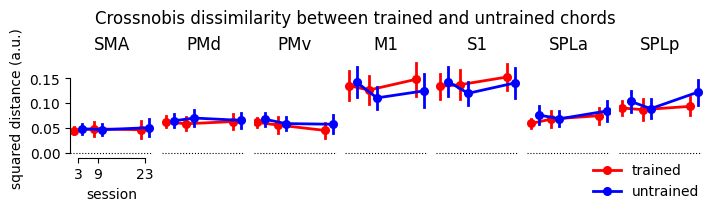

In [19]:
hue_order = ['trained', 'untrained']
palette   = ['red', 'blue']

dist = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity.within_session.ROI.glm{glm}.tsv'), sep='\t')
dist = dist[(dist.Hem=='L') & (dist.chord.isin(hue_order))]
dist_chord_sess = dist.groupby(['sn', 'Hem', 'roi', 'session', 'chord']).mean(numeric_only=True).reset_index()

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

#plot_im_sess(fig, axs, diss_within, rois, y='dist', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='box', legend=False, alpha=.3)
plot_im_sess(fig, axs, dist_chord_sess, rois, y='crossnobis', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=True)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('squared distance (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Crossnobis dissimilarity between trained and untrained chords')

ttest = ttest_im_sess(dist_chord_sess, rois, y='crossnobis', x='session', hue='chord', hue_order=hue_order)
ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
ttest.sort_values(by=['session', 'roi'], inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

fig.savefig('figures/crossnobis_mean.pdf')

plt.show()

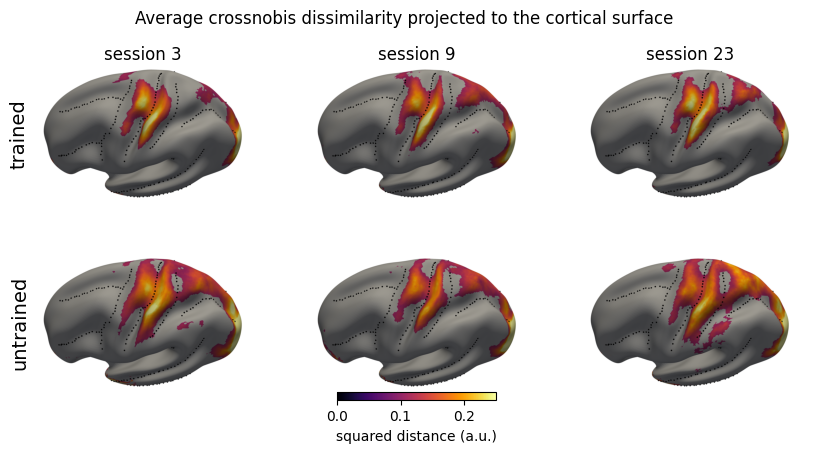

In [32]:
thresh = .1
vmin, vmax = 0, .25
H = 'L'

fig, axs = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(10, 4.5), )

cmap = 'inferno'

for s, session in enumerate(gl.sessions):
    ax       = axs[:, s]
    gifti    = nb.load(os.path.join(gl.baseDir, gl.surfDir, f'searchlight_crossnobis.{session}.glm{glm}.{H}.func.gii'))
    cols     = nt.get_gifti_column_names(gifti)
    tr_col   = cols.index('crossnobis-trained')
    untr_col = cols.index('crossnobis-untrained')
    plot_surf(fig, ax[0], gifti, H, cmap=cmap, col=tr_col, thresh=thresh, vmin=vmin, vmax=vmax)
    plot_surf(fig, ax[1], gifti, H, cmap=cmap, col=untr_col, thresh=thresh, vmin=vmin, vmax=vmax)
    ax[0].set_title(f'session {session}')

sm  = plt.cm.ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
cax = axs[1, 1].inset_axes([.15, -.10, .7, .06])          # x0, y0, w, h in axes fractions
fig.colorbar(sm, cax=cax, orientation='horizontal', label='squared distance (a.u.)')

axs[0, 0].text(0, .5, 'trained', transform=axs[0, 0].transAxes, rotation=90, ha='right', va='center', fontsize=14)
axs[1, 0].text(0, .5, 'untrained', transform=axs[1, 0].transAxes, rotation=90, ha='right', va='center', fontsize=14)

fig.suptitle('Average crossnobis dissimilarity projected to the cortical surface')

fig.savefig('figures/crossnobis_searchlight.pdf')

plt.show()

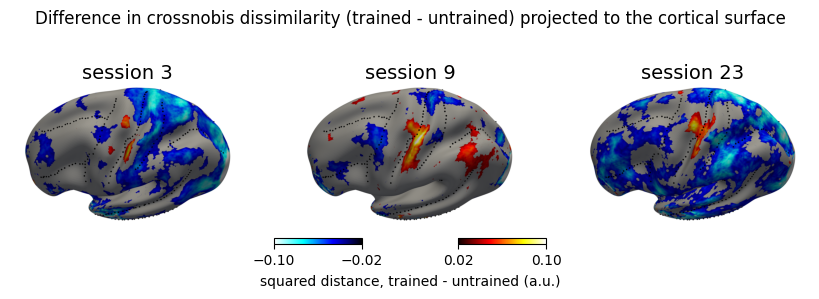

In [33]:
cold_colors = [(0, 0, 0), (0, 0, 1), (0, 1, 1), (1, 1, 1)]  # RGB tuples
cold        = LinearSegmentedColormap.from_list('cold_custom', cold_colors, N=128)
hot         = plt.cm.hot(np.linspace(0, 1, 128))
cold_vals   = cold(np.linspace(1, 0, 128))  # reversed
combined    = np.vstack((cold_vals, hot))
cmap        = LinearSegmentedColormap.from_list('coldhot', combined)

thresh = .02
vmin, vmax = -.1, .1

fig, axs = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(8, 3), )

for s, session in enumerate(gl.sessions):
    ax       = axs[s]
    gifti    = nb.load(os.path.join(gl.baseDir, gl.surfDir, f'searchlight_crossnobis_diff.{session}.glm{glm}.{H}.func.gii'))
    cols     = nt.get_gifti_column_names(gifti)
    diff_col = cols.index('trained-untrained')
    plot_surf(fig, ax, gifti, H, cmap=cmap, col=diff_col, thresh=thresh, vmin=vmin, vmax=vmax)
    ax.set_title(f'session {session}', fontsize=14)

cold_half = LinearSegmentedColormap.from_list('cold_half', combined[:128])
hot_half  = LinearSegmentedColormap.from_list('hot_half', combined[128:])

sm_neg   = plt.cm.ScalarMappable(norm=Normalize(vmin=vmin, vmax=-thresh), cmap=cold_half)
cax_neg  = fig.add_axes([.33, .2, .11, .02])
cbar_neg = fig.colorbar(sm_neg, cax=cax_neg, orientation='horizontal')
cbar_neg.set_ticks([vmin, -thresh])

sm_pos   = plt.cm.ScalarMappable(norm=Normalize(vmin=thresh, vmax=vmax), cmap=hot_half)
cax_pos  = fig.add_axes([.56, .2, .11, .02])
cbar_pos = fig.colorbar(sm_pos, cax=cax_pos, orientation='horizontal')
cbar_pos.set_ticks([thresh, vmax])

fig.supxlabel('squared distance difference, trained - untrained (a.u.)', fontsize=10, y=.05)

fig.suptitle('Difference in crossnobis dissimilarity (trained - untrained) projected to the cortical surface')

plt.subplots_adjust(left=0, right=1, bottom=.1, top=.9, hspace=0)

fig.savefig('figures/crossnobis_diff_searchlight.pdf')

plt.show()

# Cosine dissimilarity and anguglar distance between activity patterns for trained and untrained chords
The cosine dissimilairty and angular distance between activity patterns for trained chords are also wider compared to untrained chords.

           T  dof     p_val           CI95   roi  session
0  -0.636023   15  0.534347  [-0.01, 0.01]   SMA        3
3  -0.149696   15  0.882999  [-0.01, 0.01]   PMd        3
6  -0.609885   15  0.551066  [-0.02, 0.01]   PMv        3
9  -0.779728   15  0.447680  [-0.02, 0.01]    M1        3
12 -0.527081   15  0.605846  [-0.02, 0.01]    S1        3
15 -0.570809   15  0.576582  [-0.02, 0.01]  SPLa        3
18 -0.685596   15  0.503427  [-0.02, 0.01]  SPLp        3
1  -0.390236   15  0.701848  [-0.01, 0.01]   SMA        9
4   0.043138   15  0.966160  [-0.01, 0.01]   PMd        9
7   0.534853   15  0.600591  [-0.01, 0.01]   PMv        9
10 -0.171448   15  0.866163  [-0.01, 0.01]    M1        9
13  1.404976   15  0.180399   [-0.0, 0.02]    S1        9
16  1.290800   15  0.216314   [-0.0, 0.02]  SPLa        9
19 -0.647910   15  0.526837  [-0.01, 0.01]  SPLp        9
2   0.270175   15  0.790707  [-0.01, 0.02]   SMA       23
5   0.698487   15  0.495560  [-0.01, 0.01]   PMd       23
8   1.516005  

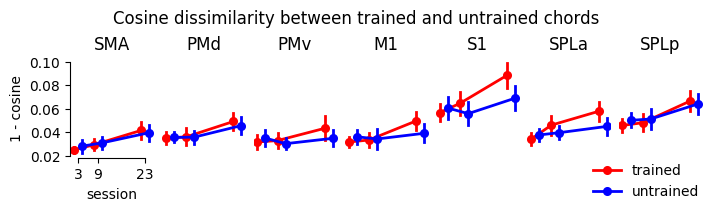

In [24]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, dist_chord_sess, rois, y='cosine', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=False)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('1 - cosine')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Cosine dissimilarity between trained and untrained chords')

ttest = ttest_im_sess(dist_chord_sess, rois, y='cosine', x='session', hue='chord', hue_order=hue_order)
ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
ttest.sort_values(by=['session', 'roi'], inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

fig.savefig('figures/cosine_mean.pdf')

plt.show()

           T  dof     p_val           CI95   roi  session
0  -0.199836   15  0.844293  [-0.05, 0.04]   SMA        3
3  -0.237246   15  0.815675  [-0.04, 0.03]   PMd        3
6  -0.489852   15  0.631325  [-0.05, 0.03]   PMv        3
9  -0.405120   15  0.691108  [-0.06, 0.04]    M1        3
12 -0.140027   15  0.890501  [-0.05, 0.04]    S1        3
15 -0.630833   15  0.537644  [-0.06, 0.03]  SPLa        3
18 -0.683744   15  0.504563  [-0.06, 0.03]  SPLp        3
1  -0.450583   15  0.658735  [-0.04, 0.03]   SMA        9
4  -0.500050   15  0.624296  [-0.04, 0.03]   PMd        9
7  -0.005777   15  0.995466  [-0.04, 0.04]   PMv        9
10  0.074932   15  0.941259  [-0.04, 0.04]    M1        9
13  1.040655   15  0.314520  [-0.02, 0.07]    S1        9
16  0.824878   15  0.422365  [-0.02, 0.05]  SPLa        9
19 -0.367968   15  0.718038  [-0.04, 0.03]  SPLp        9
2   0.074789   15  0.941371  [-0.05, 0.06]   SMA       23
5   0.695185   15  0.497568  [-0.02, 0.05]   PMd       23
8   0.998607  

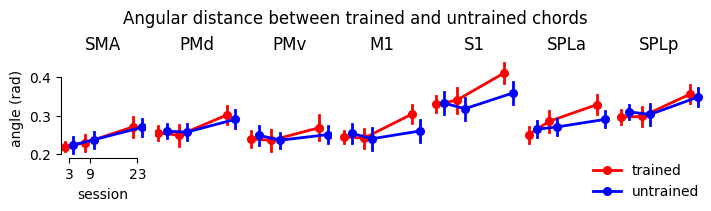

In [39]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

dist_chord_sess['theta'] = np.arccos(1 - dist_chord_sess.cosine)

plot_im_sess(fig, axs, dist_chord_sess, rois, y='theta', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=False)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('angle (rad)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Angular distance between trained and untrained chords')

ttest = ttest_im_sess(dist_chord_sess, rois, y='theta', x='session', hue='chord', hue_order=hue_order)
ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
ttest.sort_values(by=['session', 'roi'], inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

fig.savefig('figures/angle_mean.pdf')

plt.show()

# Distances adjusted based on group geometry on session 3
For 8 chords, there are 70 possible sets of trained and untrained chords. While each chord was trained in half participants and untrained in the other half, the combination of trained and untrained chords was unique in each participants. Because we only collected N=16 participants, we could not sample all the possible combinations. Therefore, is possible that the underlying geometry in each participant influences the mean distances. To account for this, we regressed out the mean geometry at session 3 across participants from the crossnobis and cosine dissimilarities in each session, as follows:

For each participant, region and session, the 12 within-set chord pairs (6 trained and 6 untrained; the 16 trained-untrained pairs are left out) were fit with

$$d_{i} = \beta_g\,\bar{d}^{\,3}_{i} + \beta_c\,c_{i} + \beta_0 + \epsilon_{i}$$

- $d_i$ is the dissimilarity (crossnobis or $1-\cos$) of chord pair $i$ in that session;
- $\bar{d}^{\,3}_{i} = \frac{1}{N}\sum_{s=1}^{N} d^{\,3}_{s,i}$ is the *group geometry*: the mean dissimilarity of the same chord pair on session 3 across all $N=16$ participants. Pairs are matched by chord ID, and the average pools over the participants for whom that pair was trained, untrained or mixed, so $\bar{d}^{\,3}$ carries no information about training. The same session-3 reference is used in every session, so $\beta_g$ measures how much of a session's geometry is still explained by the geometry at session 3;
- $c_i = +1$ for trained pairs and $c_i = -1$ for untrained pairs.

The adjusted dissimilarity of each pair is its dissimilarity with the group geometry projected out, centred on the mean of the covariate so that it stays on the scale of $d$:

$$\tilde{d}_{i} = d_{i} - \hat{\beta}_g\left(\bar{d}^{\,3}_{i} - \overline{\bar{d}^{\,3}}\right)$$

Averaging $\tilde{d}$ over the trained and over the untrained pairs of each participant gives the adjusted means plotted below, whose difference is $2\hat{\beta}_c$, and these were compared with a paired t-test in each region and session.

The adjusted cosine dissimilarity (and angular distance) was significantly different between trained and untrained chords on session 23 in M1 and S1 (as well as SPLa).

           T  dof     p_val           CI95   roi  session
0  -0.566592   15  0.579371  [-0.02, 0.01]   SMA        3
3  -0.696391   15  0.496835  [-0.02, 0.01]   PMd        3
6  -0.666361   15  0.515299  [-0.04, 0.02]   PMv        3
9  -1.542302   15  0.143831  [-0.07, 0.01]    M1        3
12 -1.238651   15  0.234509  [-0.06, 0.02]    S1        3
15 -1.366049   15  0.192056  [-0.05, 0.01]  SPLa        3
18 -0.776462   15  0.449547  [-0.04, 0.02]  SPLp        3
1   0.418839   15  0.681270  [-0.01, 0.02]   SMA        9
4  -1.233397   15  0.236407  [-0.03, 0.01]   PMd        9
7  -0.343109   15  0.736278  [-0.03, 0.03]   PMv        9
10  0.489671   15  0.631450  [-0.03, 0.04]    M1        9
13  1.274182   15  0.221987  [-0.01, 0.05]    S1        9
16  0.131800   15  0.896894  [-0.02, 0.03]  SPLa        9
19 -0.040325   15  0.968366  [-0.03, 0.02]  SPLp        9
2   0.228455   15  0.822378  [-0.04, 0.05]   SMA       23
5   0.449935   15  0.659192  [-0.02, 0.04]   PMd       23
8   0.078108  

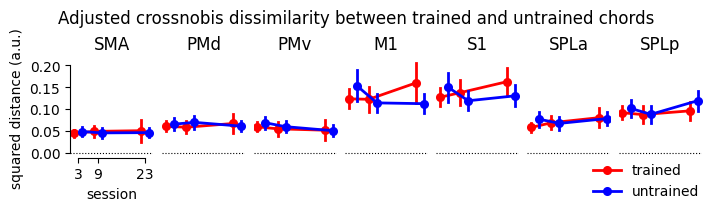

In [75]:
dist_ancova = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity_ancova.within_session.ROI.glm{glm}.tsv'), sep='\t')
dist_ancova = dist_ancova[dist_ancova.Hem==H]
dist_chord_sess_ancova = dist_ancova.groupby(['sn', 'Hem', 'roi', 'session', 'chord']).mean(numeric_only=True).reset_index()

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

#plot_im_sess(fig, axs, diss_within, rois, y='dist', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='box', legend=False, alpha=.3)
plot_im_sess(fig, axs, dist_chord_sess_ancova, rois, y='crossnobis', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=True)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('squared distance (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Adjusted crossnobis dissimilarity between trained and untrained chords')

ttest = ttest_im_sess(dist_chord_sess_ancova, rois, y='crossnobis', x='session', hue='chord', hue_order=hue_order)
ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
ttest.sort_values(by=['session', 'roi'], inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])


           T  dof     p_val           CI95   roi  session
0  -0.863180   15  0.401630  [-0.01, 0.01]   SMA        3
3  -0.494499   15  0.628117  [-0.01, 0.01]   PMd        3
6  -0.769880   15  0.453326  [-0.02, 0.01]   PMv        3
9  -1.257355   15  0.227850   [-0.02, 0.0]    M1        3
12 -0.422635   15  0.678558  [-0.02, 0.01]    S1        3
15 -0.959295   15  0.352619  [-0.02, 0.01]  SPLa        3
18 -0.296664   15  0.770791  [-0.01, 0.01]  SPLp        3
1   0.844607   15  0.411599  [-0.01, 0.02]   SMA        9
4   0.291130   15  0.774939  [-0.02, 0.02]   PMd        9
7   0.431940   15  0.671930  [-0.01, 0.02]   PMv        9
10  0.247979   15  0.807513  [-0.01, 0.02]    M1        9
13  1.368048   15  0.191443  [-0.01, 0.03]    S1        9
16  1.438603   15  0.170801   [-0.0, 0.02]  SPLa        9
19  0.001427   15  0.998880  [-0.01, 0.01]  SPLp        9
2   0.729700   15  0.476815  [-0.01, 0.03]   SMA       23
5   1.554500   15  0.140908   [-0.0, 0.03]   PMd       23
8   2.481617  

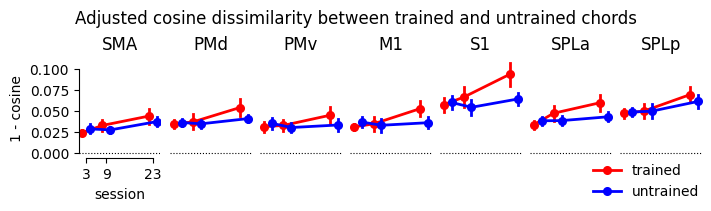

In [62]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, dist_chord_sess_ancova, rois, y='cosine', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=True)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('1 - cosine')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Adjusted cosine dissimilarity between trained and untrained chords')

ttest = ttest_im_sess(dist_chord_sess_ancova, rois, y='cosine', x='session', hue='chord', hue_order=hue_order)
ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
ttest.sort_values(by=['session', 'roi'], inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])


           T  dof     p_val           CI95   roi  session
0  -0.506670   15  0.619753  [-0.05, 0.03]   SMA        3
3  -0.633724   15  0.535806  [-0.04, 0.02]   PMd        3
6  -0.596682   15  0.559618  [-0.06, 0.03]   PMv        3
9  -0.786334   15  0.443918  [-0.06, 0.03]    M1        3
12 -0.225963   15  0.824280  [-0.04, 0.03]    S1        3
15 -1.118909   15  0.280778  [-0.06, 0.02]  SPLa        3
18 -0.422445   15  0.678693  [-0.04, 0.03]  SPLp        3
1   0.603711   15  0.555057  [-0.03, 0.06]   SMA        9
4   0.063896   14  0.949956  [-0.05, 0.05]   PMd        9
7   0.156559   15  0.877680  [-0.05, 0.06]   PMv        9
10  0.223009   15  0.826537  [-0.04, 0.05]    M1        9
13  1.206736   15  0.246221  [-0.02, 0.07]    S1        9
16  1.121693   15  0.279629  [-0.02, 0.06]  SPLa        9
19  0.235592   15  0.816935  [-0.04, 0.04]  SPLp        9
2   0.345184   15  0.734749  [-0.05, 0.07]   SMA       23
5   1.421648   15  0.175587  [-0.02, 0.08]   PMd       23
8   1.813344  

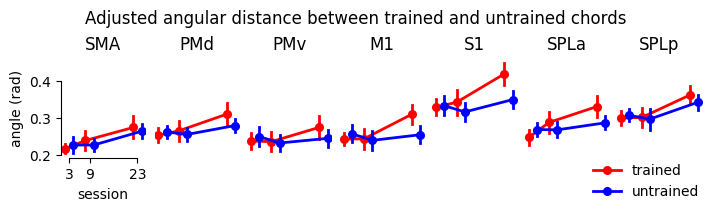

In [64]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

dist_chord_sess_ancova['theta'] = np.arccos(1 - dist_chord_sess_ancova.cosine)

plot_im_sess(fig, axs, dist_chord_sess_ancova, rois, y='theta', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=False)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('angle (rad)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Adjusted angular distance between trained and untrained chords')

ttest = ttest_im_sess(dist_chord_sess_ancova, rois, y='theta', x='session', hue='chord', hue_order=hue_order)
ttest['roi'] = pd.Categorical(ttest.roi, categories=rois, ordered=True)  # ROIs in gl.rois[atlas] order
ttest.sort_values(by=['session', 'roi'], inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

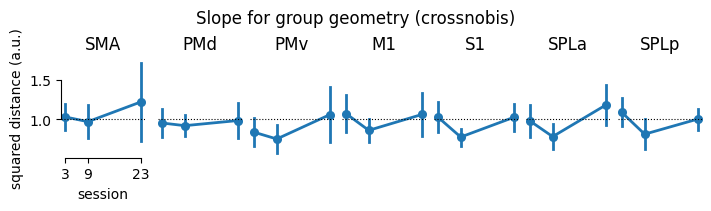

In [74]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, dist_chord_sess_ancova, rois, y='crossnobis_slope_group', x='session', kind='point', estimator='mean', dodge=.4, add_zero=1)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('squared distance (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Slope for group geometry (crossnobis)')

plt.show()

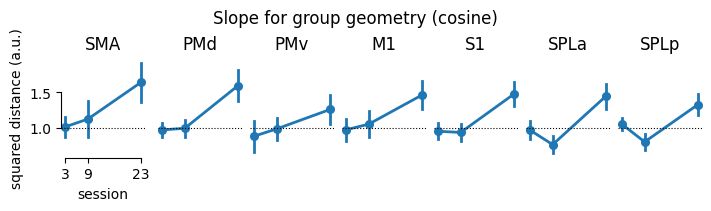

In [73]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, dist_chord_sess_ancova, rois, y='cosine_slope_group', x='session', kind='point', estimator='mean', dodge=.4, add_zero=1)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('squared distance (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Slope for group geometry (cosine)')

plt.show()

# Activity vs. dissimilarity
- Activity $a$ for trained and untrained chords was estimated from the cross-validated G-matrix as: $a = \frac{1}{K}\sum_{k=1}^{K}\sqrt{G_{kk}}$; where $K=4$ is the number of chords within the trained and untrained set.

- Dissimilarity $d$ between trained and untrained chords was estimated as the mean off-diagonal crossnobis distance $d = \frac{2}{K(K-1)}\sum_{k<l}\sqrt{D_{kl}}$ over the same conditions, with $D = $ `pcm.G_to_dist(G)`.

- The predicted dissimilarity in session 9 (and 23) if patterns only scaled with activity would be $\hat d_9 = \frac{a_9}{a_3} d_3$; $d_9 - \hat d_9$ (the `residual`) larger than 0 would occur if the patterns separated by more than a change in activity alone can account for.

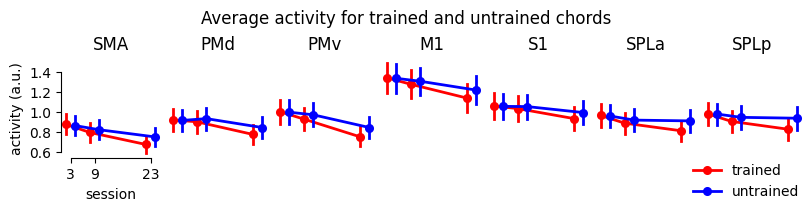

In [51]:
scaling = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'scaling.between_session.glm{glm}.{atlas}.tsv'), sep='\t')
scaling = scaling[scaling.Hem==H]

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 2), constrained_layout=True)

plot_im_sess(fig, axs, scaling, rois=rois, roi_col='roi', y='act_target', hue='chord', hue_order=hue_order, palette=palette, estimator='mean', add_zero=False, dodge=.4)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('activity (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

fig.suptitle('Average activity for trained and untrained chords')

plt.show()

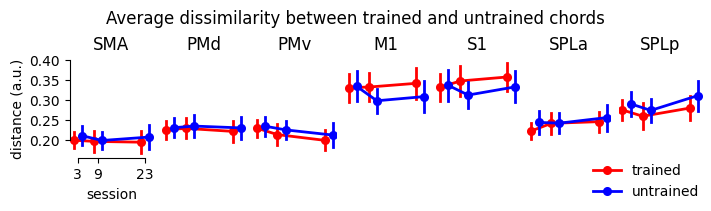

In [52]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, scaling, rois, y='diss_target_observed', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=False)

sb.despine(ax=axs[0], trim=True)
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

axs[0].set_ylabel('distance (a.u.)')

fig.suptitle('Average dissimilarity between trained and untrained chords')

plt.show()

           T  dof     p_val           CI95   roi  session
0        NaN   15       NaN     [nan, nan]   SMA        3
3        NaN   15       NaN     [nan, nan]   PMd        3
6        NaN   15       NaN     [nan, nan]   PMv        3
9        NaN   15       NaN     [nan, nan]    M1        3
12       NaN   15       NaN     [nan, nan]    S1        3
15       NaN   15       NaN     [nan, nan]  SPLa        3
18       NaN   15       NaN     [nan, nan]  SPLp        3
7   0.311292   15  0.759863  [-0.04, 0.06]   PMv        9
13  2.978445   14  0.009968   [0.01, 0.07]    S1        9
10  1.634585   14  0.124413  [-0.01, 0.09]    M1        9
4   0.354260   14  0.728423  [-0.02, 0.03]   PMd        9
1   1.132243   15  0.275308  [-0.02, 0.05]   SMA        9
16  1.624871   15  0.125012  [-0.01, 0.07]  SPLa        9
19  0.670176   15  0.512932  [-0.03, 0.06]  SPLp        9
5   1.173090   15  0.259052  [-0.01, 0.04]   PMd       23
2   1.413012   15  0.178066  [-0.01, 0.05]   SMA       23
14  2.975723  

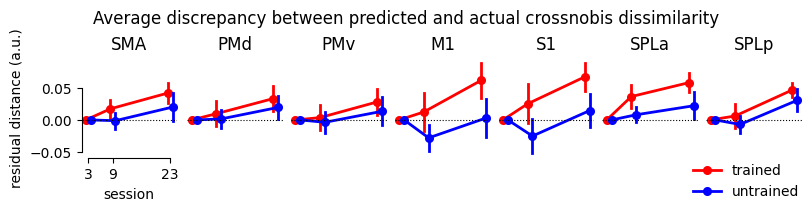

In [53]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 2), constrained_layout=True)

plot_im_sess(fig, axs, scaling, rois=rois, roi_col='roi', y='residual', hue='chord', hue_order=['trained', 'untrained'], palette=['red', 'blue'], estimator='mean', add_zero=True)
sb.despine(ax=axs[0], trim=True)
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

axs[0].set_ylabel('residual distance (a.u.)')

fig.suptitle('Average discrepancy between predicted and actual crossnobis dissimilarity')

ttest = ttest_im_sess(scaling, rois, y='residual', x='session', hue='chord', hue_order=hue_order)
ttest.sort_values(by='session', inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

plt.show()